# Classifier Compo Test

`services/forest_mask/cli.py` で追加された `anomaly_compo` を確認するノートブック。

- `classify_forest_status` -> `apply_morphology` -> `remove_small_components` の流れを再現する。
- `anomaly_morph` から小さな連結成分を除去し、 `anomaly_compo` を作る。
- 適用前後を可視化し、ピクセル数の変化と `min_size` による挙動を確認する。

入力: `data/input/jpg/sample/sample_tree.jpg`

In [1]:
# プロジェクトルートで実行できるようにカレントを移動
import os
from pathlib import Path

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
    os.chdir(PROJECT_ROOT)

print("cwd:", Path.cwd())

cwd: /home/mqsol/works/forest-analyzer


In [2]:
# モジュールリロードを有効化
%load_ext autoreload
%autoreload 2

In [3]:
# パラメータ (CLI に合わせる)
INPUT_PATH = Path("data/input/jpg/sample/sample_tree.jpg")

EXG_THRESHOLD = 10.0
SAT_TH = 80.0
LAB_A_TH = 125.0
ANOMALY_SAT_TH = 60.0
ANOMALY_VAL_TH = 170.0
TEXTURE_KERNEL = 5
TEXTURE_TH = 5.0

# anomaly_morph 用 (CLI の anomaly_morph に揃える)
ANOMALY_CLOSING = 5
ANOMALY_OPENING = 3

# anomaly_compo 用
MIN_SIZE = 300

In [4]:
# 特徴量計算 -> 分類 -> モルフォロジー -> 連結成分フィルタ
from services.common.image import load_rgb
from services.forest_mask.exg import calc_exg
from services.forest_mask.color import calc_hsv, calc_lab
from services.forest_mask.texture import calc_texture
from services.forest_mask.classifier import classify_forest_status
from services.forest_mask.morphology import apply_morphology
from services.forest_mask.components import remove_small_components

rgb = load_rgb(INPUT_PATH)
exg = calc_exg(rgb)
hsv_h, hsv_s, hsv_v = calc_hsv(rgb)
lab_l, lab_a, lab_b = calc_lab(rgb)
texture = calc_texture(exg, TEXTURE_KERNEL)

healthy_mask, anomaly_mask, unknown_mask = classify_forest_status(
    exg=exg,
    s=hsv_s,
    v=hsv_v,
    lab_a=lab_a,
    texture=texture,
    exg_threshold=EXG_THRESHOLD,
    saturation_threshold=SAT_TH,
    lab_a_threshold=LAB_A_TH,
    anomaly_saturation_threshold=ANOMALY_SAT_TH,
    anomaly_value_threshold=ANOMALY_VAL_TH,
    texture_threshold=TEXTURE_TH,
)

anomaly_morph = apply_morphology(anomaly_mask, ANOMALY_CLOSING, ANOMALY_OPENING)
anomaly_compo = remove_small_components(anomaly_morph, min_size=MIN_SIZE)

total = rgb.shape[0] * rgb.shape[1]
rows = [
    ("anomaly_mask", anomaly_mask),
    ("anomaly_morph", anomaly_morph),
    ("anomaly_compo", anomaly_compo),
]
for name, m in rows:
    pix = int(m.sum())
    print(f"{name:14s}: {pix:>10d} px  ({pix / total * 100:5.2f}%)")

anomaly_mask  :     286567 px  ( 9.12%)
anomaly_morph :     441677 px  (14.06%)
anomaly_compo :     368939 px  (11.74%)


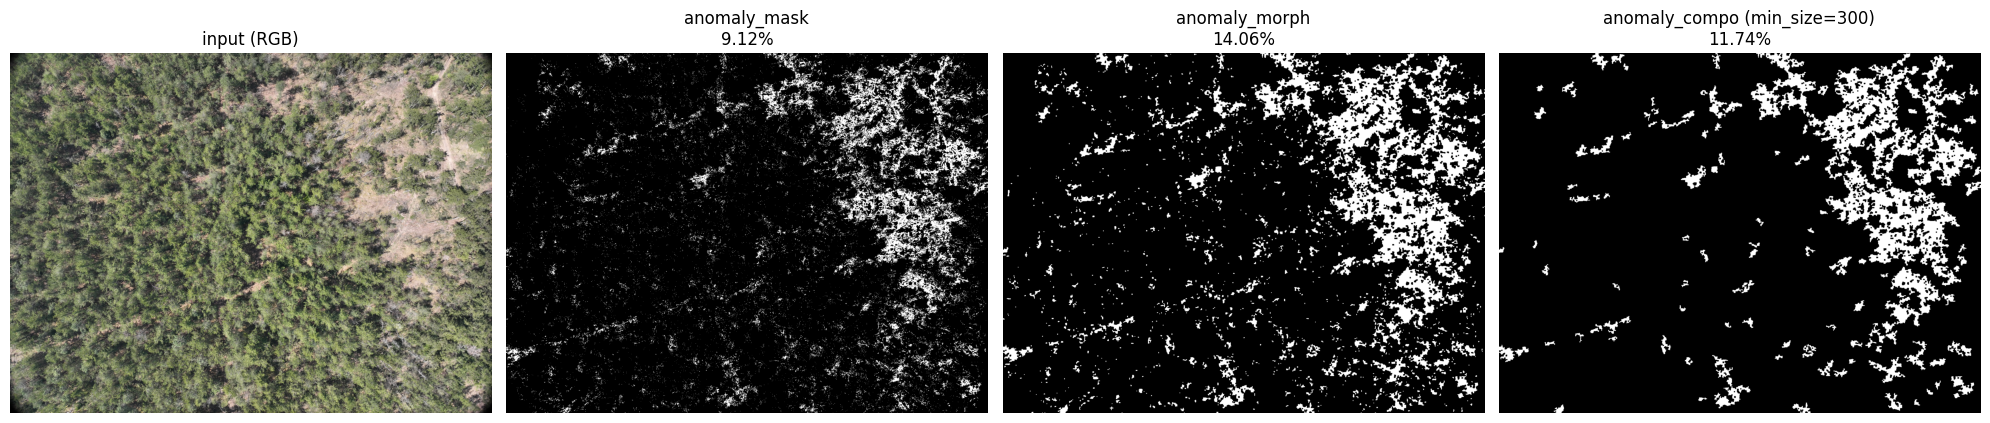

In [5]:
# 入力 + 3 段階のマスクを横並びで比較
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

axes[0].imshow(rgb)
axes[0].set_title("input (RGB)")
axes[0].axis("off")

for ax, mask, name in [
    (axes[1], anomaly_mask, "anomaly_mask"),
    (axes[2], anomaly_morph, "anomaly_morph"),
    (axes[3], anomaly_compo, f"anomaly_compo (min_size={MIN_SIZE})"),
]:
    ax.imshow(mask, cmap="gray", vmin=0, vmax=1)
    pix = int(mask.sum())
    ax.set_title(f"{name}\n{pix / total * 100:.2f}%")
    ax.axis("off")

plt.tight_layout()
plt.show()

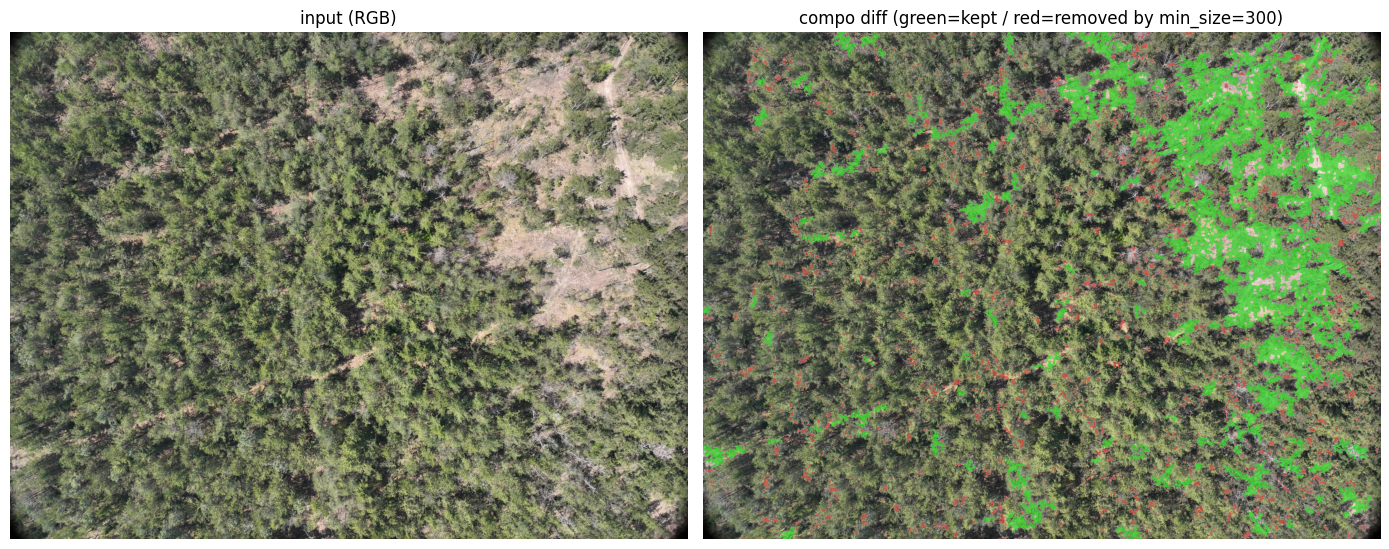

kept   :     368939 px  (11.74%)
removed:      72738 px  ( 2.32%)


In [6]:
# remove_small_components で除去された画素を可視化
#   残った画素 = 緑 / 除去された画素 = 赤
import numpy as np

ALPHA = 0.55
kept = anomaly_compo
removed = anomaly_morph & ~anomaly_compo

overlay = rgb.astype(np.float32).copy()
overlay[kept] = (1 - ALPHA) * overlay[kept] + ALPHA * np.array([0, 220, 0], dtype=np.float32)
overlay[removed] = (1 - ALPHA) * overlay[removed] + ALPHA * np.array([220, 30, 30], dtype=np.float32)
overlay = np.clip(overlay, 0, 255).astype(np.uint8)

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
axes[0].imshow(rgb)
axes[0].set_title("input (RGB)")
axes[0].axis("off")
axes[1].imshow(overlay)
axes[1].set_title(f"compo diff (green=kept / red=removed by min_size={MIN_SIZE})")
axes[1].axis("off")
plt.tight_layout()
plt.show()

print(f"kept   : {int(kept.sum()):>10d} px  ({kept.sum() / total * 100:5.2f}%)")
print(f"removed: {int(removed.sum()):>10d} px  ({removed.sum() / total * 100:5.2f}%)")

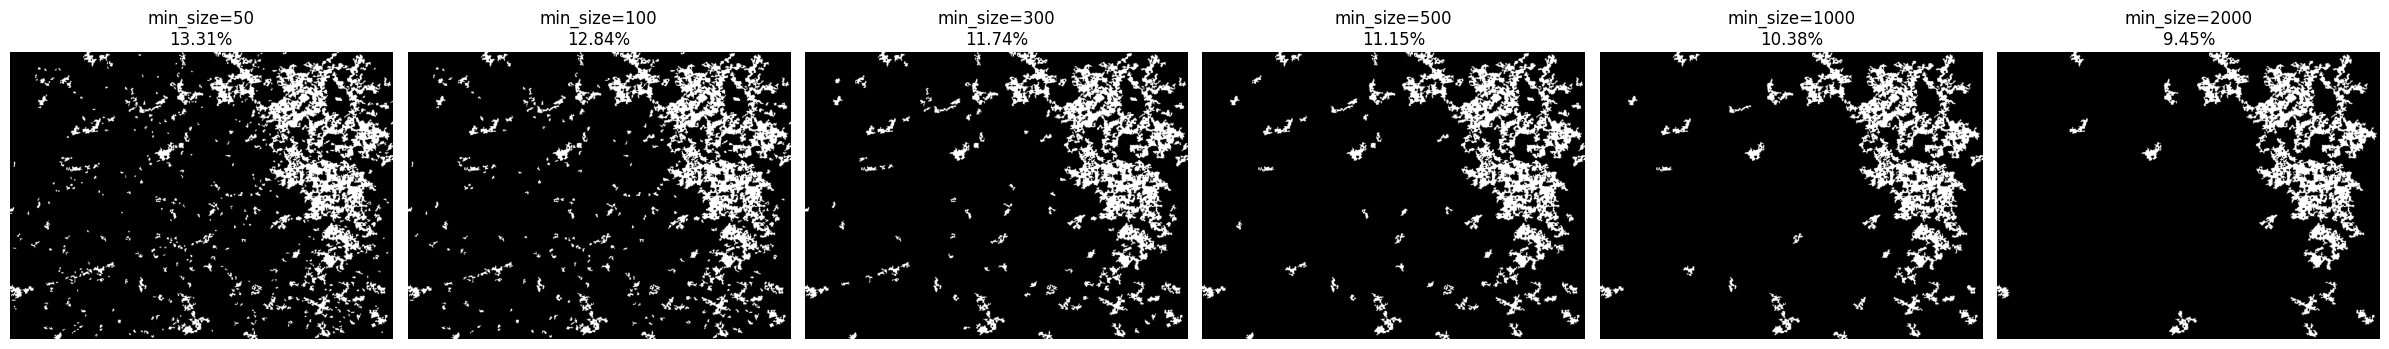

In [7]:
# min_size をスイープして挙動を確認
min_sizes = [50, 100, 300, 500, 1000, 2000]

fig, axes = plt.subplots(1, len(min_sizes), figsize=(4 * len(min_sizes), 4))
for ax, ms in zip(axes, min_sizes):
    compo = remove_small_components(anomaly_morph, min_size=ms)
    pix = int(compo.sum())
    ax.imshow(compo, cmap="gray", vmin=0, vmax=1)
    ax.set_title(f"min_size={ms}\n{pix / total * 100:.2f}%")
    ax.axis("off")

plt.tight_layout()
plt.show()

components: 1637
  min : 6
  max : 122064
  mean: 269.8


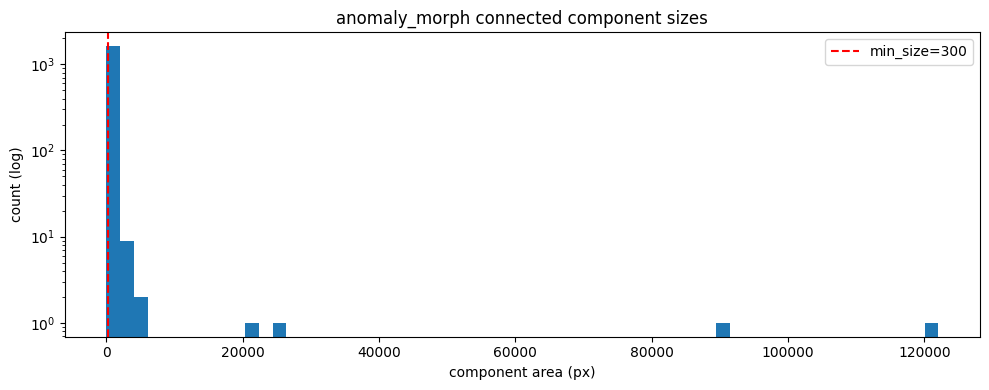

In [8]:
# anomaly_morph の連結成分サイズ分布を確認 (min_size の目安)
import cv2

num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(
    anomaly_morph.astype(np.uint8),
    connectivity=8,
)
areas = stats[1:, cv2.CC_STAT_AREA]
print(f"components: {len(areas)}")
print(f"  min : {areas.min() if len(areas) else 0}")
print(f"  max : {areas.max() if len(areas) else 0}")
print(f"  mean: {areas.mean() if len(areas) else 0:.1f}")

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(areas, bins=60)
ax.set_yscale("log")
ax.axvline(MIN_SIZE, color="red", linestyle="--", label=f"min_size={MIN_SIZE}")
ax.set_xlabel("component area (px)")
ax.set_ylabel("count (log)")
ax.set_title("anomaly_morph connected component sizes")
ax.legend()
plt.tight_layout()
plt.show()